# 03 — Supervised baselines, stated honestly (2026 refresh)

**Question this notebook answers:** how well can the three 2020 classifiers predict a KOI's archive disposition, and how much of that skill is real physics versus reading the vetting flags?

**Inputs:** the cleaned table from `kepler.preprocess.clean` (notebook 01). **Outputs:** `reports/tables/03_baseline_metrics.csv` and figures in `reports/figures/models/`.

> **What changed since 2020** (details: *notes/Research Log/2026-08-24 Review 03_sklearn_models*)
> - The 2020 numbers are reproduced first, on the 2020 split, with the 2020 hyperparameters — then re-labelled correctly: **83 / 90 / 90 were accuracy and weighted f1; macro f1 is 0.77 / 0.87 / 0.87.**
> - Every result names its feature set: `legacy_2020` (23 columns), `with_flags` (physics + the 4 vetting flags), `physics_only`.
> - A zero-parameter rule ("any flag → FALSE POSITIVE") sits in the table as a baseline. It matches the models on the FALSE POSITIVE class.
> - 5-fold cross-validation with error bars replaces the single split; the scaler lives inside the pipeline; no hyperparameter is chosen on the test set.
> - `log1p` on heavy-tailed columns, which the review found closes most of the linear model's gap.
> - The stale-`y_pred` bug (cell 44 in 2020) cannot recur: scoring goes through `kepler.models.fit_and_score`.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kepler import data, preprocess, viz
from kepler.data import CLASSES, TARGET
from kepler.models import (
    cv_macro_f1, fit_and_score, flag_rule, legacy_models, log1p_scaled, scaled, score, split,
)
from kepler.paths import FIGURES, REPORTS

warnings.filterwarnings("ignore", category=FutureWarning)
viz.apply_style()
FIG_DIR = FIGURES / "models"; FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = REPORTS / "tables"; TABLE_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 160); pd.set_option("display.precision", 4)

## 1. Data and the evaluation rows

To compare feature sets fairly, every model below sees **the same 8,945 KOIs**: the rows that are complete on the 2020 columns. (The physics-only set could keep 9,200 rows, and a NaN-native model all 9,564; that upgrade is Phase 3.) Target codes: 0 CANDIDATE, 1 CONFIRMED, 2 FALSE POSITIVE.

In [2]:
clean = preprocess.clean(data.load_kaggle_snapshot())
legacy = preprocess.model_table(clean, "legacy_2020")
X_all, y_all = legacy.X, legacy.y
print("rows:", len(X_all), "| dropped by dropna on the 2020 columns:", legacy.n_dropped)
SETS = {name: preprocess.FEATURE_SETS[name] for name in ("legacy_2020", "with_flags", "physics_only")}
pd.Series({k: len(v) for k, v in SETS.items()}, name="columns").to_frame()

rows: 8945 | dropped by dropna on the 2020 columns: 619


,columns
legacy_2020,23
with_flags,16
physics_only,12


## 2. The 2020 baseline, reproduced and re-labelled

Same split (`random_state=1`, stratified, 25% test), same hyperparameters, `StandardScaler` fit on the training rows. The 2020 deck quoted the **accuracy / weighted-f1** column as "f1"; the macro and per-class columns are what the two classes we care about actually score.

In [3]:
X_train, X_test, y_train, y_test = split(X_all, y_all)
print("train/test:", len(X_train), len(X_test), "| test classes:", y_test.value_counts().sort_index().tolist())

rows = {}
for name, est in legacy_models().items():
    rows[name] = fit_and_score(scaled(est), X_train, y_train, X_test, y_test).as_row()
rows["flag_rule (any flag -> FP, else CONFIRMED)"] = score(y_test, flag_rule(X_test)).as_row()
baseline_2020 = pd.DataFrame(rows).T
baseline_2020.style.format("{:.4f}").set_caption("legacy_2020 feature set, 2020 split")

train/test: 6708 2237 | test classes: [534, 572, 1131]


,accuracy,balanced_accuracy,f1_macro,f1_weighted,f1_CANDIDATE,f1_CONFIRMED,f1_FALSE POSITIVE
logistic_regression,0.8324,0.7726,0.7729,0.8298,0.6278,0.7001,0.9908
gradient_boosting,0.9021,0.8691,0.8706,0.9015,0.8045,0.8172,0.9899
balanced_random_forest,0.8994,0.8652,0.8670,0.8987,0.7989,0.8131,0.9890
"flag_rule (any flag -> FP, else CONFIRMED)",0.7550,0.6591,0.5550,0.6733,0.0000,0.6743,0.9908


> **Reading the table.** The FALSE POSITIVE column is 0.99 for every model **and for the one-line flag rule**: that class is being looked up, not learned. The honest headline for 2020 is macro f1 0.77 / 0.87 / 0.87 (logistic regression / gradient boosting / balanced random forest), with CANDIDATE and CONFIRMED at 0.63–0.82.

## 3. Same split, three feature sets

Now the leakage question directly: what happens to each model when the four flags go, and when the provenance columns go too?

In [4]:
records = []
for set_name, cols in SETS.items():
    for model_name, est in legacy_models().items():
        s = fit_and_score(scaled(est), X_train[cols], y_train, X_test[cols], y_test)
        records.append({"feature_set": set_name, "model": model_name, **s.as_row()})
single_split = pd.DataFrame(records)
pivot = single_split.pivot(index="model", columns="feature_set", values="f1_macro")[list(SETS)]
pivot.style.format("{:.3f}").set_caption("macro f1 on the 2020 test split")

feature_set,legacy_2020,with_flags,physics_only
model,,,
balanced_random_forest,0.867,0.862,0.709
gradient_boosting,0.871,0.860,0.717
logistic_regression,0.773,0.747,0.541


In [5]:
per_class = single_split.melt(id_vars=["feature_set", "model"], value_vars=[f"f1_{c}" for c in CLASSES],
                              var_name="class", value_name="f1")
per_class["class"] = per_class["class"].str.replace("f1_", "")
per_class.pivot_table(index=["model", "class"], columns="feature_set", values="f1")[list(SETS)].round(3)

feature_set                            legacy_2020  with_flags  physics_only
model                  class                                                
balanced_random_forest CANDIDATE             0.799       0.796         0.561
                       CONFIRMED             0.813       0.800         0.758
                       FALSE POSITIVE        0.989       0.990         0.808
gradient_boosting      CANDIDATE             0.805       0.787         0.553
                       CONFIRMED             0.817       0.803         0.764
                       FALSE POSITIVE        0.990       0.990         0.835
logistic_regression    CANDIDATE             0.628       0.582         0.248
                       CONFIRMED             0.700       0.667         0.588
                       FALSE POSITIVE        0.991       0.991         0.787

## 4. Cross-validation with error bars

One split cannot tell 0.871 from 0.867. Five stratified folds, scaler inside the pipeline, macro f1 per fold.

In [6]:
cv_records = []
for set_name, cols in SETS.items():
    for model_name, est in legacy_models().items():
        mean, std, folds = cv_macro_f1(scaled(est), X_all[cols], y_all, n_splits=5, random_state=0)
        cv_records.append({"feature_set": set_name, "model": model_name, "f1_macro_mean": mean, "f1_macro_std": std,
                           **{f"fold{i}": v for i, v in enumerate(folds)}})
cv = pd.DataFrame(cv_records)
cv.pivot(index="model", columns="feature_set", values="f1_macro_mean")[list(SETS)].round(3).astype(str) + " ± " + \
    cv.pivot(index="model", columns="feature_set", values="f1_macro_std")[list(SETS)].round(3).astype(str)

feature_set,legacy_2020,with_flags,physics_only
model,,,
balanced_random_forest,0.867 ± 0.005,0.86 ± 0.007,0.715 ± 0.003
gradient_boosting,0.866 ± 0.009,0.861 ± 0.007,0.715 ± 0.015
logistic_regression,0.768 ± 0.014,0.741 ± 0.016,0.527 ± 0.006


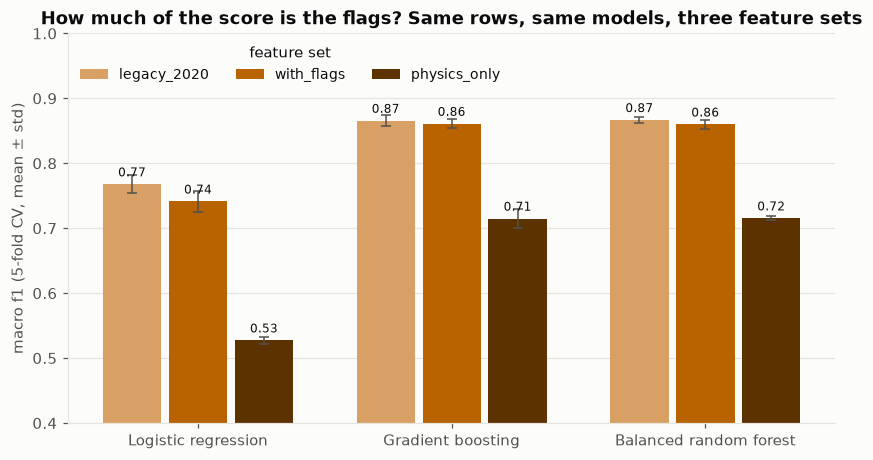

In [7]:
models = list(legacy_models())
labels = {"logistic_regression": "Logistic regression", "gradient_boosting": "Gradient boosting",
          "balanced_random_forest": "Balanced random forest"}
fig, ax = viz.new_figure(9, 4.6)
width = 0.26
x = np.arange(len(models))
for i, set_name in enumerate(SETS):
    sub = cv.set_index(["model", "feature_set"]).loc[[(m, set_name) for m in models]]
    bars = ax.bar(x + (i - 1) * width, sub["f1_macro_mean"], width - 0.03, yerr=sub["f1_macro_std"],
                  color=viz.FEATURE_SET_COLORS[set_name], label=set_name, capsize=3,
                  error_kw={"elinewidth": 1, "ecolor": viz.TEXT_SECONDARY})
    for b, v in zip(bars, sub["f1_macro_mean"]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.2f}", ha="center", fontsize=8, color=viz.TEXT_PRIMARY)
ax.set_xticks(x); ax.set_xticklabels([labels[m] for m in models])
ax.set_ylim(0.4, 1.0); ax.set_ylabel("macro f1 (5-fold CV, mean ± std)")
ax.set_title("How much of the score is the flags? Same rows, same models, three feature sets")
ax.legend(title="feature set", loc="upper left", ncols=3)
ax.grid(axis="x", visible=False)
fig.savefig(FIG_DIR / "macro_f1_by_feature_set.png")
plt.show()

> **Reading the figure.** Removing the four flags costs every model roughly 0.15 of macro f1; the provenance columns (RA/Dec, delivery name, TCE number) add almost nothing on top of the flags. The physics-only column is the honest baseline the rest of the project builds on.

## 5. Heavy tails: `log1p` for the linear model

Insolation, planet radius and transit depth span five decades. Standardising them leaves a linear model unable to use most of their range; a `log1p` before scaling fixes that. Trees do not care.

In [8]:
log_records = []
for set_name in ("with_flags", "physics_only"):
    cols = SETS[set_name]
    for variant, pipe in (("scaled", scaled(legacy_models()["logistic_regression"])),
                          ("log1p + scaled", log1p_scaled(legacy_models()["logistic_regression"], cols))):
        s = fit_and_score(pipe, X_train[cols], y_train, X_test[cols], y_test)
        mean, std, _ = cv_macro_f1(pipe, X_all[cols], y_all, n_splits=5, random_state=0)
        log_records.append({"feature_set": set_name, "variant": variant, "f1_macro_split": s.f1_macro,
                            "f1_macro_cv": mean, "f1_macro_cv_std": std, "accuracy_split": s.accuracy})
pd.DataFrame(log_records).round(3)

,feature_set,variant,f1_macro_split,f1_macro_cv,f1_macro_cv_std,accuracy_split
0,with_flags,scaled,0.747,0.741,0.016,0.814
1,with_flags,log1p + scaled,0.838,0.841,0.007,0.878
2,physics_only,scaled,0.541,0.527,0.006,0.638
3,physics_only,log1p + scaled,0.667,0.668,0.006,0.704


## 6. Where the physics-only model goes wrong

Confusion matrices for gradient boosting on the test split, with and without the flags. Rows are the truth, columns the prediction.

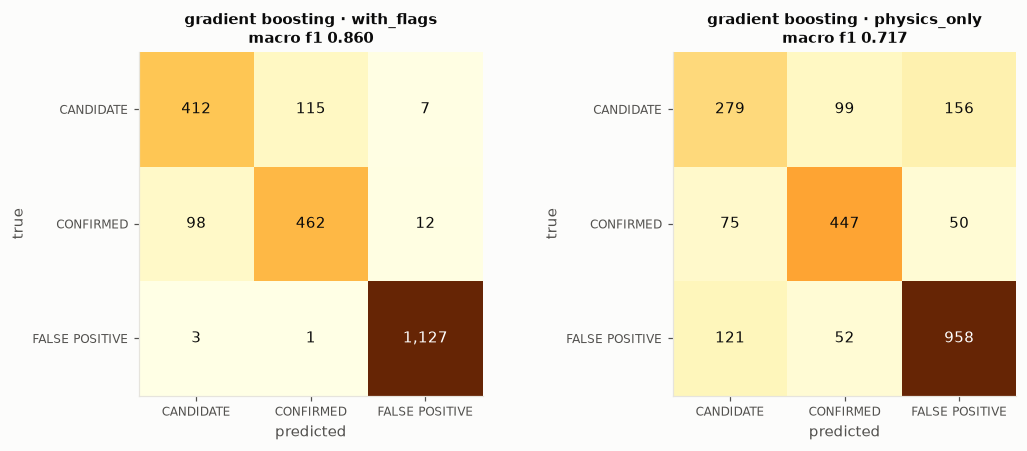

In [9]:
gbt = legacy_models()["gradient_boosting"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, set_name in zip(axes, ("with_flags", "physics_only")):
    cols = SETS[set_name]
    s = fit_and_score(scaled(gbt), X_train[cols], y_train, X_test[cols], y_test)
    cm = s.confusion
    im = ax.imshow(cm, cmap=viz.SEQUENTIAL_CMAP, vmin=0, vmax=cm.max())
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=10,
                    color="white" if cm[i, j] > 0.6 * cm.max() else viz.TEXT_PRIMARY)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASSES, fontsize=8); ax.set_yticklabels(CLASSES, fontsize=8)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"gradient boosting · {set_name}\nmacro f1 {s.f1_macro:.3f}", fontsize=10)
    ax.grid(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "confusion_gbt_flags_vs_physics.png")
plt.show()

> Without the flags, the model still separates planets from most false positives on physics alone (transit depth, signal-to-noise, radius), but it can no longer tell CANDIDATE from CONFIRMED well: that distinction comes from follow-up observations that are not in this table at all.

## 7. Save

In [10]:
out = pd.concat([
    baseline_2020.reset_index().rename(columns={"index": "model"}).assign(feature_set="legacy_2020", evaluation="2020 split"),
    single_split.assign(evaluation="2020 split"),
    cv.assign(evaluation="5-fold CV"),
], ignore_index=True)
out.insert(0, "run_date", "2026-08-24")
path = TABLE_DIR / "03_baseline_metrics.csv"
out.to_csv(path, index=False)
print("wrote", path.relative_to(REPORTS.parent), out.shape)

wrote reports/tables/03_baseline_metrics.csv (22, 18)


## Summary

- **2020, correctly labelled:** logistic regression / gradient boosting / balanced random forest reach macro f1 **0.77 / 0.87 / 0.87** on the 2020 split (accuracy 0.83 / 0.90 / 0.90 is what the deck called "f1").
- **The flags are the score:** a one-line rule gets FALSE POSITIVE f1 0.99; dropping the flags costs every model about 0.15 of macro f1 in cross-validation.
- **Provenance columns add nothing** once the flags are present, and the physics-only feature set is the honest baseline.
- **Error bars matter:** fold-to-fold spread is about the size of the differences between the tree models.
- **Next (Phase 3):** NaN-native gradient boosting on all 9,564 rows, missingness indicators, calibrated probabilities, and the live table.